<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/13_resampling-methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 13:  Resampling methods

This homework assignment is designed to give you practice with bootstrapping and permutation tests.

You will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.

This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measuresments from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework/hcp_data* folder in the class GitHub repository.

---
## 1. Loading & Visualizing the Data (1 point)

Use the `setwd` and `read.csv` functions to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file.

(a) Using the tidyverse tools, make a new dataframe `d1` that only inclues the subject ID (`Subject`), gender (`Gender`, self reported at time of data collection), Flanker Task performance (`Flanker_Unadj`), total intracranial volume (`FS_IntraCranial_Vol`), total white matter volume (`FS_Tot_WM_Vol`), and total grey matter volume (`FS_Total_GM_Vol`) variables and remove all _na_ values.

Use the `head` function to look at the first few rows of each data frame.

In [2]:
# Load tidyverse
library(tidyverse)

# Set working directory and load data
setwd("/Users/belinda/Desktop/85403/GitHub/DataSciencePsychNeuro/Exercise datasets/hcp_data")
df <- read.csv("unrestricted_trimmed_1_7_2020_10_50_44.csv")

# Create d1 with selected columns and remove NAs
d1 <- df %>%
  select(Subject, Gender, Flanker_Unadj, FS_IntraCranial_Vol, FS_Tot_WM_Vol, FS_Total_GM_Vol) %>%
  drop_na()

# View first few rows
head(d1)

,Subject,Gender,Flanker_Unadj,FS_IntraCranial_Vol,FS_Tot_WM_Vol,FS_Total_GM_Vol
,<int>,<chr>,<dbl>,<dbl>,<int>,<int>
1,100206,M,130.42,1864518,543134,807245
2,100307,F,112.56,1512540,407292,664124
3,100408,M,121.18,1684117,500417,726206
4,100610,M,126.53,1816044,512946,762308
5,101006,F,101.85,1437868,429449,579632
6,101107,M,107.04,1512727,416995,665024


(b) Plot grey matter volume (x axis) against intracranial volume (y axis) and Gender (point color).

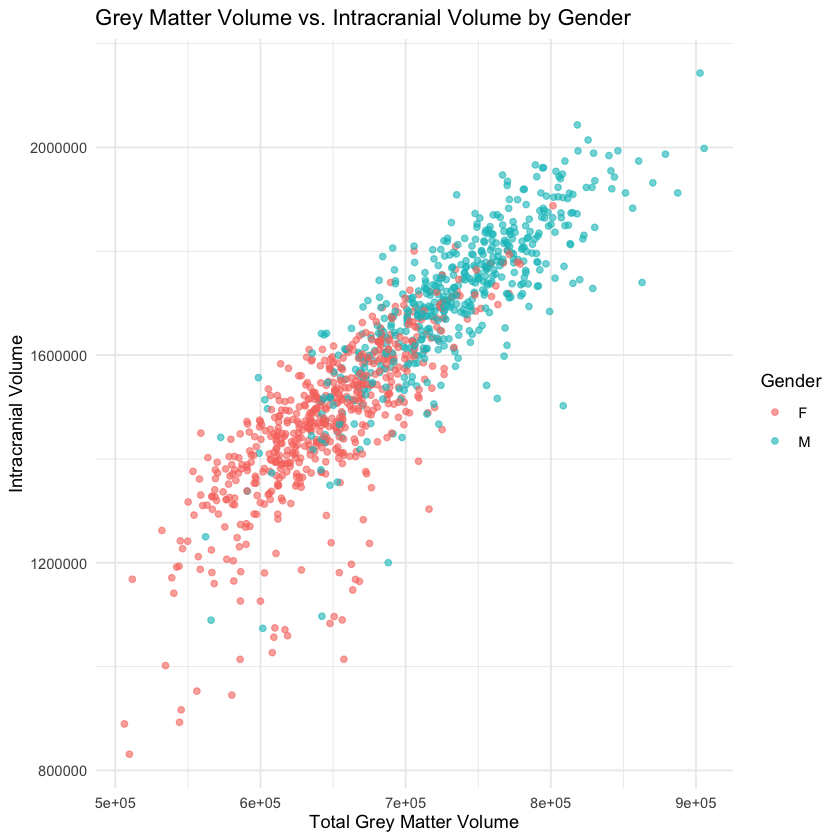

In [3]:
ggplot(d1, aes(x = FS_Total_GM_Vol, y = FS_IntraCranial_Vol, color = Gender)) +
  geom_point(alpha = 0.6) +
  labs(
    x = "Total Grey Matter Volume",
    y = "Intracranial Volume",
    color = "Gender",
    title = "Grey Matter Volume vs. Intracranial Volume by Gender"
  ) +
  theme_minimal()

What patterns do you observe in the scatter plot?

> It seems like there is a clear positive correlation between total grey matter column and intracranial volume. As grey matter volume increases, intracranial volume tends to increase as well. And this trend tend to happen for both genders.
> 
> Also, males (teal dots) and females (salmon dots) formed pretty distinct clusters. Males tend to cluster toward the upper-right of the plot (comparatively larger grey matter volumes and intracranial volumes), while females tend to cluster toward the lower-left (relatively smaller volumes on both measures).
> 
> Despite the group-level differences, there is a considerable overlap between males and females in the middle range of the plot. This would indicate that although there are differences in group averages, many individual males and females still exhibit similar volumns in both measures.

---
## 2. Logistic classifier (2 points)

We want to try predicting gender using the neural data you have loaded.

(a) Run a logisic regression model to predict gender from total white matter volume, total grey matter volume, and intracranial volume.

In [6]:
# Convert Gender to a factor
d1$Gender <- as.factor(d1$Gender)

# Run logistic regression
model <- glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol,
             data = d1,
             family = binomial)

# View model summary
summary(model)


Call:
glm(formula = Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol, 
    family = binomial, data = d1)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -2.262e+01  1.347e+00 -16.787  < 2e-16 ***
FS_Tot_WM_Vol        2.140e-06  3.059e-06   0.699    0.484    
FS_Total_GM_Vol      1.959e-05  3.145e-06   6.229 4.70e-10 ***
FS_IntraCranial_Vol  5.020e-06  1.177e-06   4.263 2.01e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1534.13  on 1112  degrees of freedom
Residual deviance:  919.85  on 1109  degrees of freedom
AIC: 927.85

Number of Fisher Scoring iterations: 5


Which factors are signficantly associated with gender?

> Total grey matter volume and intracranial volume, which both had p values less than 0.001.

(b) Estimate the prediction accuracy of your model (Note: this is the training set accuracy). Set your prediction threshold to 0.5.

In [7]:
# Get predicted probabilities from the model
predicted_probs <- predict(model, type = "response")

# Convert probabilities to class predictions using 0.5 threshold
predicted_gender <- ifelse(predicted_probs > 0.5, "M", "F")

# Calculate accuracy by comparing predictions to actual values
accuracy <- mean(predicted_gender == d1$Gender)

# Print the accuracy
cat("Training set accuracy:", accuracy, "\n")

# View the confusion matrix
table(Predicted = predicted_gender, Actual = d1$Gender)

Training set accuracy: 0.8203055 


         Actual
Predicted   F   M
        F 516 110
        M  90 397

What is the prediction accuracy for gender from the full model?

> Based on the output, the accuracy is around 82.03%, which is not bad. And if we look closer into the confusion matrix, the model correctly identified 516 out of 606 females (85.1% sensitivity for females). It correctly identified 397 out of 507 males (78.3% sensitivity for males). 110 males were misclassified as female while 90 females were misclassified as male. This is showing that the model is slightly better at identifying females than males. Overall, the accuracy of 82.03% is fairly strong for the model.

---
## 3. Bootstrapped accuracy (3 points)

Use bootstrapping to estimate the confidence intervals of the _prediction accuracy_ of your model (i.e., the confidence of the correlation between $\hat{y}$ and $y$). Plot the histogram of the bootstrapped prediction accuracies and estimate the confidence intervals off of the standard deviation from the bootstrap.


[1] 0.8203055

ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = d1, statistic = boot.fn, R = 1000)


Bootstrap Statistics :
     original       bias    std. error
t1* 0.8203055 8.984726e-06  0.01279163
Bootstrap mean accuracy: 0.8203145 
Bootstrap SD: 0.01279163 
95% CI: [ 0.7947312 , 0.8458977 ]


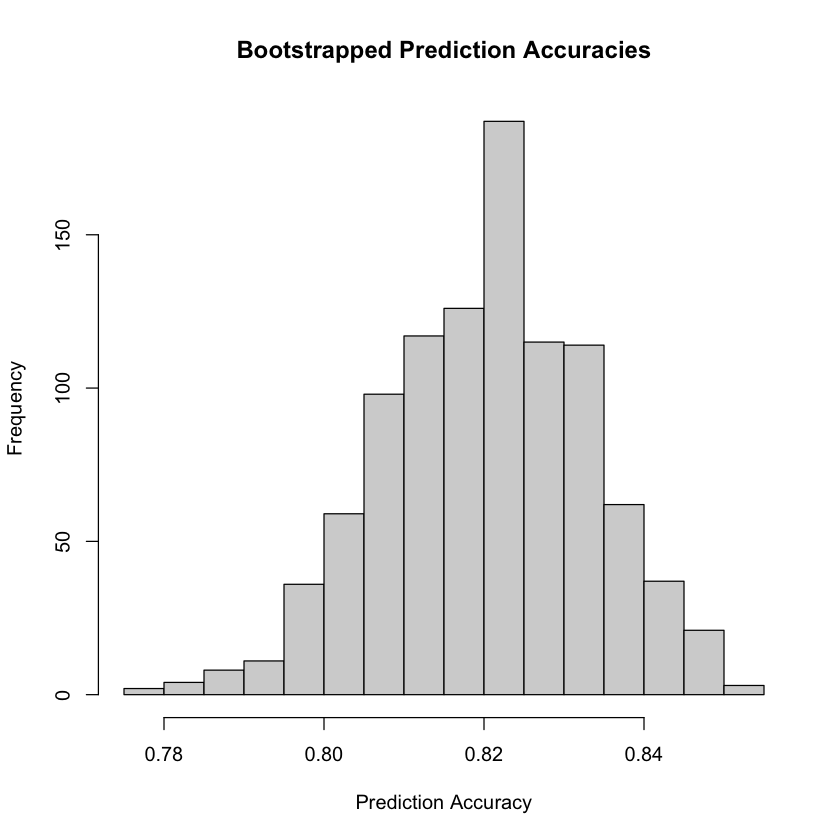

In [8]:
library(boot)

# Bootstrap function
boot.fn <- function(data, index) {
    # Fit logistic regression on bootstrapped sample
    model <- glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol,
                 data = data, subset = index, family = binomial)
    
    # Get predicted probabilities and classify with 0.5 threshold
    predicted_probs <- predict(model, newdata = data[index, ], type = "response")
    predicted_gender <- ifelse(predicted_probs > 0.5, "M", "F")
    
    # Return accuracy
    return(mean(predicted_gender == data[index, ]$Gender))
}

# Test on full dataset
print(boot.fn(d1, 1:nrow(d1)))

# Run bootstrap with 1000 repetitions
boot_obj <- boot(d1, boot.fn, R = 1000)
print(boot_obj)

# Plot histogram of bootstrapped accuracies
hist(boot_obj$t[,1], xlab = "Prediction Accuracy", main = "Bootstrapped Prediction Accuracies")

# Estimate confidence interval using mean +/- 2*SD
boot_mean <- mean(boot_obj$t[,1])
boot_sd <- sd(boot_obj$t[,1])
ci_lower <- boot_mean - 2 * boot_sd
ci_upper <- boot_mean + 2 * boot_sd

cat("Bootstrap mean accuracy:", boot_mean, "\n")
cat("Bootstrap SD:", boot_sd, "\n")
cat("95% CI: [", ci_lower, ",", ci_upper, "]\n")

How robust is the prediction accuracy of the full model?

> The prediction accuracy of the full model is pretty robust I would say. The 95% CI is [0.7947, 0.8459], which is relatively tight range with around 5 percentage points. Also, the bootstramp SD is only 0.0128, which is a very little variability in accuracy across the 1000 resampled datasets. So the model performs consistently in this case regardless of which observations are sampled. Also, the bias is essentially zero, meaning the bootstramp mean accuracy (0.8203) is kind of identical to origional accuracy (0.8203). So the origional estimate is not overly optimistic or influenced by any specific subset of the data.
>
> The histogram is showing a roughly bell-shaped distribution centered around 0.82, with most bootstrap estimates falling between 0.80 and 0.84. And there is no severe skewness or problematic outliers. Notably, even the lower end of the confidence interval (~79.5%) is substantially above the 50% baseline (random guessing), so the model does capture a reliable signal.

---
## 4. Permutation test for grey matter effects (3 points)

Now run a permutation test, with 1000 iterations, to evaluate how much grey matter volume contributes to the prediction accuracy. Compare the prediction accuracy of the full (unpermuted model) with the distribution of accuracies you get with a randomized grey matter volume term using a histogram (Hint: use the `abline` function to show the original accuracy on the histogram).

Original accuracy: 0.8203055 
Mean permuted accuracy: 0.8053702 
Permutation p-value: 0 


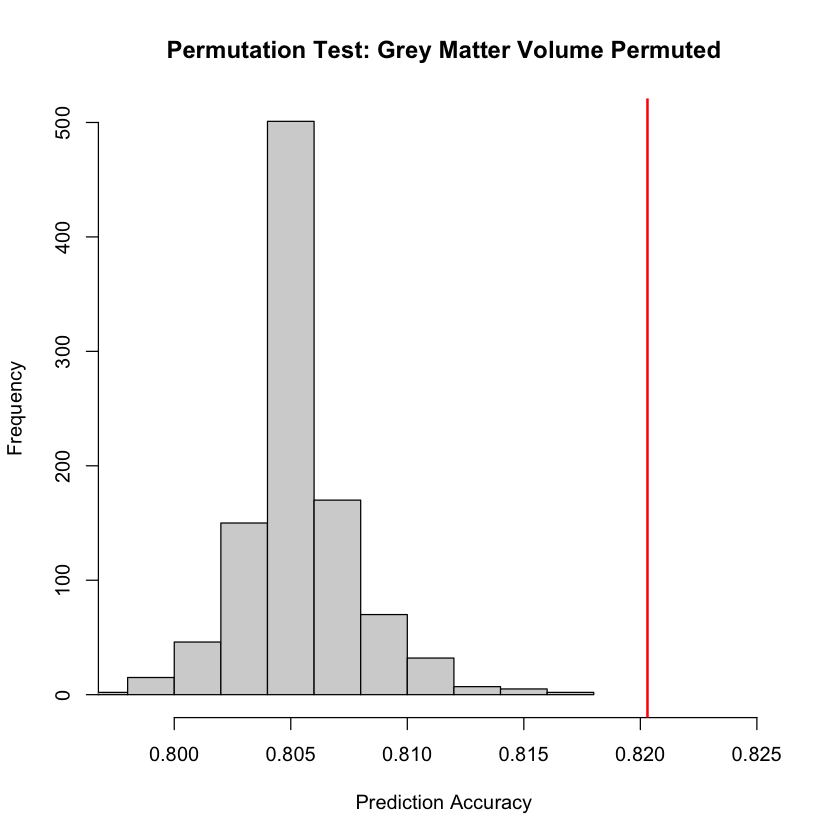

In [17]:
# Partially adapted from tutorial:

# First let's make a copy of the data set that we'll keep permuting
permD1 <- d1  # want to preserve the non-permuted, true form of data!

# Set the number of iterations
R <- 1000

# Next make an output object to store the results
perm.accuracies <- rep(NA, R)  # filling with NAs at first

# Now just write a for loop where we scramble the observations
# in grey matter volume using the sample() function
for (i in 1:R) {
    permD1$FS_Total_GM_Vol <- d1$FS_Total_GM_Vol[sample(nrow(d1))]  # Shuffled version of grey matter volume
    
    # Fit logistic regression on permuted data
    perm.model <- glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol,
                      data = permD1, family = binomial)
    
    # Get predicted probabilities and classify
    perm.probs <- predict(perm.model, type = "response")
    perm.predicted <- ifelse(perm.probs > 0.5, "M", "F")
    
    # Store accuracy
    perm.accuracies[i] <- mean(perm.predicted == permD1$Gender)
}

# Now show the real (unpermuted) accuracy on the histogram
perm.real <- accuracy  # the original accuracy we calculated earlier (0.8203055)

# Take a look at the null distribution
hist(perm.accuracies, xlab = "Prediction Accuracy", 
     main = "Permutation Test: Grey Matter Volume Permuted",
     xlim = c(min(perm.accuracies), max(perm.real, max(perm.accuracies)) + 0.005))

abline(v = perm.real, col = "red", lwd = 2)

# Sum the accuracies greater than or equal to the real accuracy
# and divide by R to get an empirical p-value
perm.p <- sum(perm.accuracies >= perm.real) / R
cat("Original accuracy:", perm.real, "\n")
cat("Mean permuted accuracy:", mean(perm.accuracies), "\n")
cat("Permutation p-value:", perm.p, "\n")

How much does the grey matter volume influence the prediction accuracy of the model?

> The permutation test shows that when grey matter volume is shuffled, prediction accuracy drops from 82.03% to approximately 80.54%. There is a decrease about 1.5 percentage points. The p value lower than 0.001 alsi indicates that none of the 1000 permutations produced accuracy as high as the real model. So this is highly unlikely to occur by chance. Thus, the grey matter volume makes a statistically significant contribution to the model's prediction accuracy. The origional accuracy falls completely outside of the null distrubution, confirming that the grey matter colume pprovides unique predictive information about gender beyond what other variables already capture.

---
## 5. Reflection (1 point)

Differentiate the bootstrap from a permutation test. Describe each and when is it appropriate to each.

> Bootstrapping is a resampling technique where we repeatedly draw samoles with replacement from the origional datasets and compute a statistic of interest like accuracy, mean, etc. on each resample. It answers the question: "What range of values can I expect for my statistic, given the variability in my data?" or "How stable/reliable is my estimate?" In our assignment, we bootstrapped the model's prediction accuracy to estimate how stable that 82.03% figure is, producing a 95% CI of [0.7947, 0.8459].
>
> Permutation testing, on the other hand, breaks the structure between specific variables of interest while preserving relationships among others. Here, we repeatedly shuffle the values of a specific variable to break its relationship with the outcome, then recompute the statistic. This creates a null distribution representing what we would expect if there were no real effect. It answers the question: "Is this effect real, or could it have occurred by chance?" In our assignment, we permuted grey matter volume to test whether it significantly contributes to prediction accuracy.
>
> Both methods are valuable as non-parametric approaches as they do not require assumptions about the functional form of data for uncertainty estimation or hypothesis testing. However, use bootstrapping when you want to quantify uncertainty around an estimate. And instead, use permutation tests when you want to test whether a specific effect of relationship is statistically significant without relying on parametric assumptions like normality.

**DUE:** 5pm EST, March 24, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*